# Wildlife Strike Damage Prediction
## CS 363M Machine Learning

**Team Members:** Ameera Habib, Anjali Kaimal, Brianna Flores, Mrinalini Jithendra

## Project Overview

Within this notebook, we are predicting whether a wildlife strike causes damage to aircrafts. We do this using FAA wildlife strike records from the years 1990 to 2026. 

# Data Cleaning

We are starting off by loading the training and test datasets, as well as an initial inspection of their structure. By doing this we are able to observe that the training set has 307,178 rows and 55 columns. 

Indicated damage is the class label we want to predict

In [425]:
import pandas as pd
import matplotlib.pyplot as plt

Checking information about the data

In [426]:
train_data = pd.read_csv('train.csv', header='infer')
test_data = pd.read_csv('test.csv', header='infer')
print("Number of rows and columns in training data: ", train_data.shape)
train_data.head()
train_data.info()

/var/folders/j1/9v5pdr3x0yq9w6b8wmphvp2c0000gn/T/ipykernel_65762/15802462.py:1: DtypeWarning: Columns (8,9,20) have mixed types. Specify dtype option on import or set low_memory=False.
  train_data = pd.read_csv('train.csv', header='infer')
/var/folders/j1/9v5pdr3x0yq9w6b8wmphvp2c0000gn/T/ipykernel_65762/15802462.py:2: DtypeWarning: Columns (8,9,20,37) have mixed types. Specify dtype option on import or set low_memory=False.
  test_data = pd.read_csv('test.csv', header='infer')


Number of rows and columns in training data:  (307178, 55)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307178 entries, 0 to 307177
Data columns (total 55 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   INDEX_NR              307178 non-null  int64  
 1   INCIDENT_DATE         307178 non-null  object 
 2   INCIDENT_MONTH        307178 non-null  int64  
 3   INCIDENT_YEAR         307178 non-null  int64  
 4   TIME                  197926 non-null  object 
 5   TIME_OF_DAY           173207 non-null  object 
 6   AIRPORT_ID            307178 non-null  object 
 7   AIRPORT               307178 non-null  object 
 8   LATITUDE              266434 non-null  object 
 9   LONGITUDE             266431 non-null  object 
 10  RUNWAY                231593 non-null  object 
 11  STATE                 266434 non-null  object 
 12  FAAREGION             266434 non-null  object 
 13  LOCATION              39218 non-null   object

### Initial Observations

We are able to observe that:
- The dataset has **55** columns and consists of a mix of numeric, string and obkect types
- There are several columns that are significantly missing data 
- LATITUDE AND LONGITUDE are stored as object type which is due to mixed formatting
- Our target variable INDICATED_DAMAGE has no missing values!


In [427]:
train_data.describe()

,INDEX_NR,INCIDENT_MONTH,INCIDENT_YEAR,EMA,EMO,AC_MASS,NUM_ENGS,ENG_1_POS,ENG_2_POS,ENG_3_POS,ENG_4_POS,HEIGHT,SPEED,DISTANCE,OUT_OF_RANGE_SPECIES,REMAINS_COLLECTED,REMAINS_SENT,TRANSFER,INDICATED_DAMAGE
count,3.071780e+05,307178.000000,307178.000000,204757.000000,194002.00000,219732.000000,219481.000000,219461.000000,204669.000000,12356.000000,3269.000000,152981.000000,95102.000000,203875.000000,307178.000000,307178.000000,307178.000000,307178.0,307178.000000
mean,1.030746e+06,7.221136,2013.629697,19.308815,8.15889,3.557770,2.004328,2.722128,2.546287,2.909922,2.162435,882.259627,142.973061,0.878159,0.000856,0.538925,0.179821,0.0,0.063569
std,3.851711e+05,2.750603,8.991125,10.573812,11.50024,0.865756,0.409663,2.117692,1.958387,1.938278,1.466136,1858.178379,46.550616,3.687059,0.029248,0.498483,0.384039,0.0,0.243984
min,6.082420e+05,1.000000,1990.000000,1.000000,0.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,7.054882e+05,5.000000,2008.000000,10.000000,1.00000,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,0.000000,120.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
50%,8.052665e+05,8.000000,2015.000000,22.000000,4.00000,4.000000,2.000000,1.000000,1.000000,1.000000,1.000000,50.000000,140.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.000000
75%,1.437907e+06,9.000000,2021.000000,31.000000,10.00000,4.000000,2.000000,5.000000,5.000000,5.000000,4.000000,1000.000000,160.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.000000
max,1.825451e+06,12.000000,2026.000000,47.000000,97.00000,5.000000,4.000000,7.000000,7.000000,6.000000,5.000000,32000.000000,541.000000,99.000000,1.000000,1.000000,1.000000,0.0,1.000000


### Removing Duplicate Rows

In [428]:
print("Number of duplicate rows", train_data.duplicated().sum())
train_data.drop_duplicates()
# Shape of dataset remained the same, no duplicates found in training dataset

Number of duplicate rows 0


,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,...,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,...,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,...,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,...,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1
3,654676,10/8/02,10,2002,NaN,NaN,KLAX,LOS ANGELES INTL,33.94254,-118.40807,...,NaN,10-Feb,Medium,NaN,2002-10-8-111929 /Legacy Record 216397/,FAA Form 5200-7-E,Carcass Found,1/9/03,0,0
4,629708,2/3/97,2,1997,NaN,Dawn,PHLI,LIHUE ARPT,21.97598,-159.33896,...,1,1,Medium,NaN,SOURCE 5200-7 & PACIR /Legacy Record 121531/,Multiple,NaN,3/1/07,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307173,1786439,10/31/25,10,2025,,NaN,KVNC,VENICE MUNICIPAL AIRPORT,27.07161,-82.44033,...,NaN,1,Medium,NaN,NaN,FAA Form 5200-7-E,Carcass Found,1/2/26,0,0
307174,676049,8/20/06,8,2006,NaN,NaN,KORD,CHICAGO O'HARE INTL ARPT,41.9796,-87.90446,...,NaN,1,Small,NaN,2006-9-5-121657 /Legacy Record 237856/,FAA Form 5200-7-E,Carcass Found,11/16/06,0,0
307175,991735,5/31/19,5,2019,11:59,NaN,KTOA,ZAMPERINI FIELD ARPT,33.80338,-118.3396,...,NaN,1,Small,NaN,NaN,MOR,Tower,6/17/20,0,0
307176,1525457,6/22/20,6,2020,8:42,NaN,KDAL,DALLAS LOVE FIELD ARPT,32.84711,-96.85177,...,NaN,1,Small,NaN,NaN,FAA Form 5200-7-E,Carcass Found,5/20/24,0,0


## Dimensionality Reduction: Dropping Columns

In [429]:
null_column_totals = train_data.isnull().sum().sort_values(ascending=False)
print("Number missing values for each column\n", null_column_totals)

Number missing values for each column
 BIRD_BAND_NUMBER        306465
ENG_4_POS               303909
ENROUTE_STATE           301832
PRECIPITATION           295966
ENG_3_POS               294822
LOCATION                267960
SPEED                   212076
NUM_SEEN                208546
SKY                     162825
FLT                     161435
HEIGHT                  154197
TIME_OF_DAY             133971
PHASE_OF_FLIGHT         120961
REG                     118982
AMO                     116813
EMO                     113176
TIME                    109252
DISTANCE                103303
COMMENTS                103083
ENG_2_POS               102509
EMA                     102421
AMA                      88896
TYPE_ENG                 87786
ENG_1_POS                87717
NUM_ENGS                 87697
AC_MASS                  87446
AC_CLASS                 87315
RUNWAY                   75585
LONGITUDE                40747
FAAREGION                40744
STATE                    40744


We will scan for any duplicate records in the training dataset and remove to prevent any bias in the training set simply due to repeated records. We however do not drop any records in the test dataset so that it can align with the expected output.

### Determining columns to drop

In [430]:
print("Shape of data before dropping columns:", train_data.shape)
train_data = train_data.drop(columns=["FLT", "REG", "AMO", "EMO", "TIME", "EMA", "AMA"])

# Drop Airports since AIRPORT is just name corresponding to AIRPORT_ID (reduce dimensionality)
train_data = train_data.drop(columns=["AIRPORT"])
# Drop LOCATION or standardize: many null values, inconsistent data format (FOUND AT KATL; DRO-DEN; Found KMEM; Waldorf, MD, 15 MILES KADW)
train_data = train_data.drop(columns=["LOCATION"])
# Drop OPERATOR since OPERATOR is name that corresponds to OPID (reduce dimensionality)
train_data = train_data.drop(columns=["OPERATOR"])
# Drop BIRD_BAND_NUMBER: Many empty values (Imputation may lead to incorrect results) and not relevant
train_data = train_data.drop(columns=["BIRD_BAND_NUMBER"])
# Drop SPECIES: SPECIES_ID is corresponding ID for common name (SPECIES)
train_data = train_data.drop(columns=["SPECIES"])
# COMMENTS: just notes, string data
train_data = train_data.drop(columns=["COMMENTS"])
# REMARKS: just notes, string data
train_data = train_data.drop(columns=["REMARKS"])
# Drop Source: Type of report filed, may not be needed to predict indicated damage
train_data = train_data.drop(columns=["SOURCE"])
# Drop Person: Role of person who filed report, dont need for prediction
train_data = train_data.drop(columns=["PERSON"])
# Drop INDEX_NR: never use index as a feature value in the dataset
train_data = train_data.drop(columns=["INDEX_NR"])
# Drop LUPDATE: since this is just the last time the record was updated in database, not really relevant to damage
train_data = train_data.drop(columns=["LUPDATE"])
# Drop TRANSFER: internal database flag
train_data = train_data.drop(columns=["TRANSFER"])

# NOTE: we found that STATE and FAAREGION were correlated and when one was null, so was the other
# decided to remove FAAREGION 
state = train_data["STATE"].isnull()
faaregion = train_data["FAAREGION"].isnull()
shared_null = (state & faaregion).sum()
print(shared_null)
train_data = train_data.drop(columns=["FAAREGION"])


# FOR ENROUTE STATE: corresponding state column is typically empty, fill with ENROUTE STATE if present
# Perform operations on test_data to apply same feature engineering to test and training set
test_data = test_data.drop(columns=["FLT", "REG", "AMO", "EMO", "TIME", "EMA", "AMA", "AIRPORT", "LOCATION", "OPERATOR", "BIRD_BAND_NUMBER", "SPECIES", "COMMENTS", "REMARKS", "SOURCE", "PERSON", "INDEX_NR", "LUPDATE", "FAAREGION", "TRANSFER"])

# Add YEARS_SINCE_START feature early so it's available throughout
train_data["YEARS_SINCE_START"] = train_data["INCIDENT_YEAR"] - 1990
test_data["YEARS_SINCE_START"] = test_data["INCIDENT_YEAR"] - 1990
print("Shape of data after dropping columns:", train_data.shape)

Shape of data before dropping columns: (307178, 55)
40744
Shape of data after dropping columns: (307178, 36)


# Data Exploration

We will explore the distribution of the target variable, teh geographic spread of incidents, and identify all potential outliers. These insights will help us and directly inform our feature engineering decisions.

<Axes: xlabel='INDICATED_DAMAGE'>

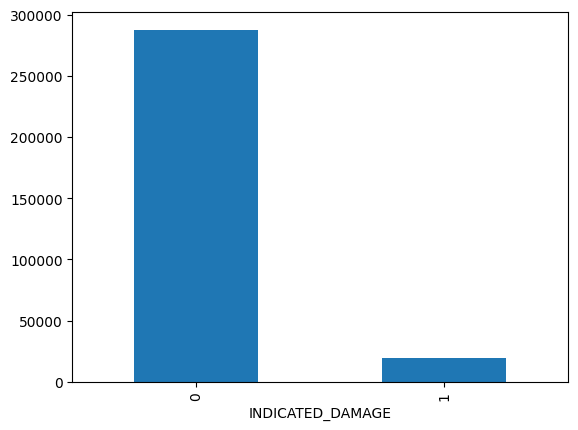

In [431]:
# This will display the distribution of the target variable, whether wildlife strike caused damage
# NOTES: this is an imbalanced distribution, we should not use typical accuracy as a metric
train_data["INDICATED_DAMAGE"].value_counts().plot.bar()

In [432]:
# Display the number of strikes based on state
train_data["STATE"].value_counts()

STATE
TX    27546
FL    22494
CA    21454
NY    14422
CO    13472
      ...  
MB       15
MH       12
NL        5
SK        5
NS        3
Name: count, Length: 67, dtype: int64

## Determining Outliers using Box Plots

INCIDENT_MONTH             Axes(0.125,0.814746;0.133621x0.0652542)
INCIDENT_YEAR           Axes(0.285345,0.814746;0.133621x0.0652542)
AC_MASS                  Axes(0.44569,0.814746;0.133621x0.0652542)
NUM_ENGS                Axes(0.606034,0.814746;0.133621x0.0652542)
ENG_1_POS               Axes(0.766379,0.814746;0.133621x0.0652542)
ENG_2_POS                  Axes(0.125,0.736441;0.133621x0.0652542)
ENG_3_POS               Axes(0.285345,0.736441;0.133621x0.0652542)
ENG_4_POS                Axes(0.44569,0.736441;0.133621x0.0652542)
HEIGHT                  Axes(0.606034,0.736441;0.133621x0.0652542)
SPEED                   Axes(0.766379,0.736441;0.133621x0.0652542)
DISTANCE                   Axes(0.125,0.658136;0.133621x0.0652542)
OUT_OF_RANGE_SPECIES    Axes(0.285345,0.658136;0.133621x0.0652542)
REMAINS_COLLECTED        Axes(0.44569,0.658136;0.133621x0.0652542)
REMAINS_SENT            Axes(0.606034,0.658136;0.133621x0.0652542)
INDICATED_DAMAGE        Axes(0.766379,0.658136;0.133621x0.0652

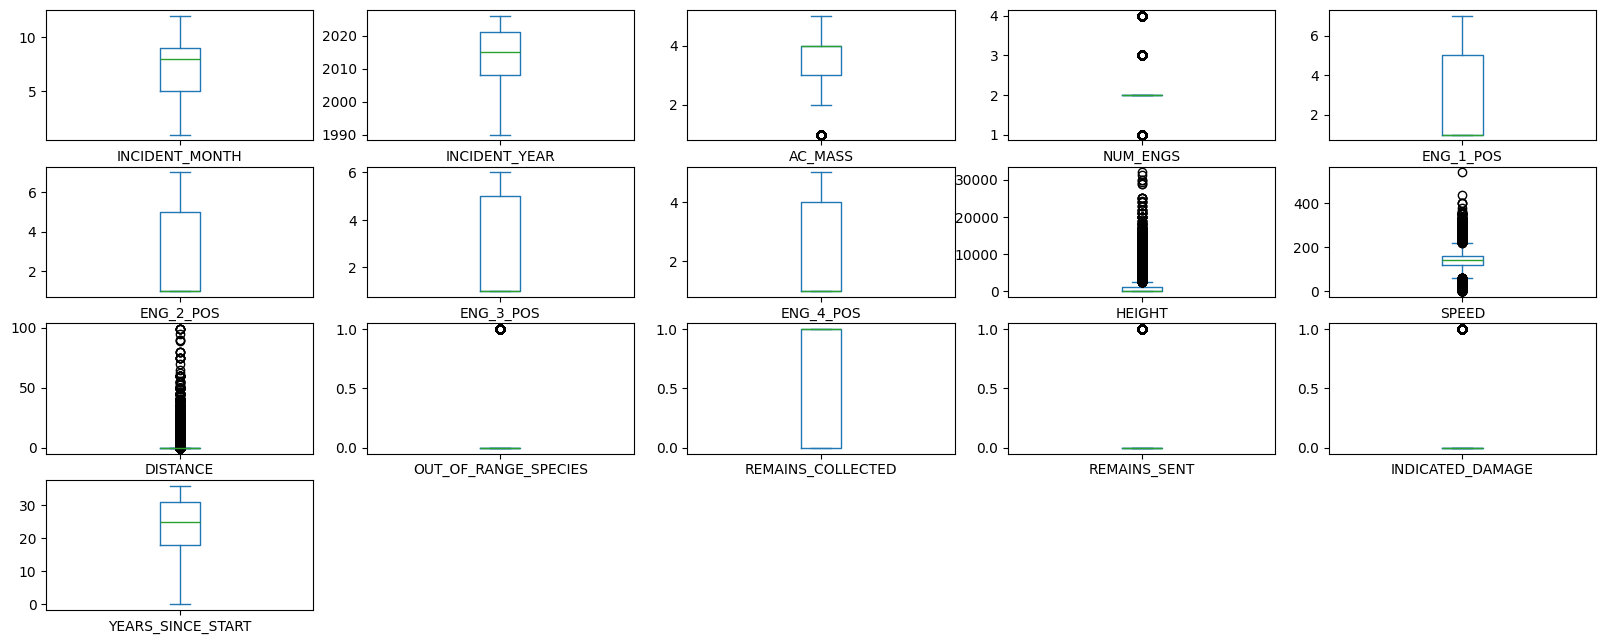

In [433]:
# Selects only the numeric columns from the dataset and visualizes their distributions using box plots to detect outliers and distribution patterns
numeric_columns = train_data.select_dtypes(include='number')
numeric_columns.plot(kind='box', subplots=True, layout=(10, 5), figsize=(20,20))

### Damage Rate by Phase of Flight

Enroute strikes have the highest damage rate by a significant amount (approximately 29%), which is then followed by Climb and Descent (both approximately 15%). This is definitely a contrast to the ground-level phases such as Parked and Taxi (which have very low rates around <5%).

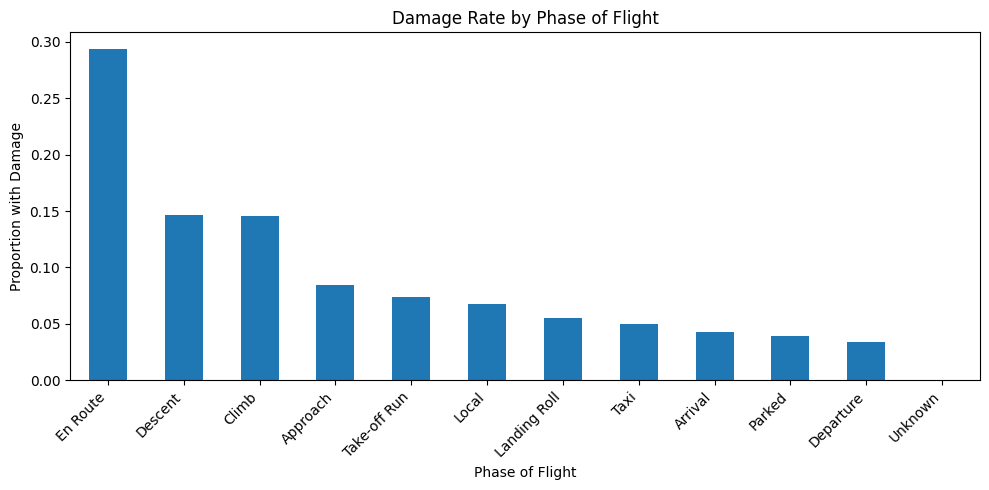

In [434]:
phase_damage = train_data.groupby('PHASE_OF_FLIGHT')['INDICATED_DAMAGE'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5)) 
phase_damage.plot(kind='bar')
plt.title('Damage Rate by Phase of Flight') 
plt.ylabel('Proportion with Damage') 
plt.xlabel('Phase of Flight') 
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()


### HEIGHT and SPEED Distribution by Damage Class

Both the distributions of HEIGHT AND SPEED are greatly skewed to the right; we can observe that most strikes are occurring at low altitudes and typical speeds. The damage class is largely hidden by the no damage class because of the class imbalance. The strikes that resulted in damage tended to be more spread across higher heights and speeds. This directly motivated our HEIGHT_SPEED feature 


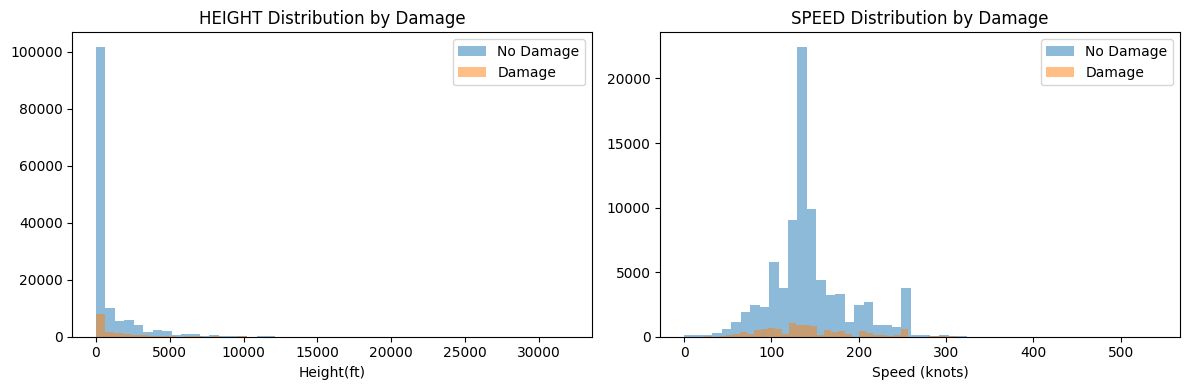

In [435]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))


for damage_val, group in train_data.groupby('INDICATED_DAMAGE'):
    label = 'Damage' if damage_val == 1 else 'No Damage'
    axes[0].hist(group['HEIGHT'],bins=50,alpha=0.5, label=label)
    axes[1].hist(group['SPEED'], bins=50,alpha=0.5, label=label)


axes[0].set_title('HEIGHT Distribution by Damage')
axes[0].set_xlabel('Height(ft)')
axes[0].legend()


axes[1].set_title('SPEED Distribution by Damage')
axes[1].set_xlabel('Speed (knots)')
axes[1].legend()


plt.tight_layout()
plt.show()


## Damage Rate by Bird Size

By exploring Damage Rate by Bird Size, we can see that larger birds (size 3) cause damage around 32% of the time which is a stark contrast to the approximately 2% for small birds. This clear relationship between Damage Rate and Bird Size motivates our ‘SEVERITY’ feature which is a combination of bird size and number of birds struck.


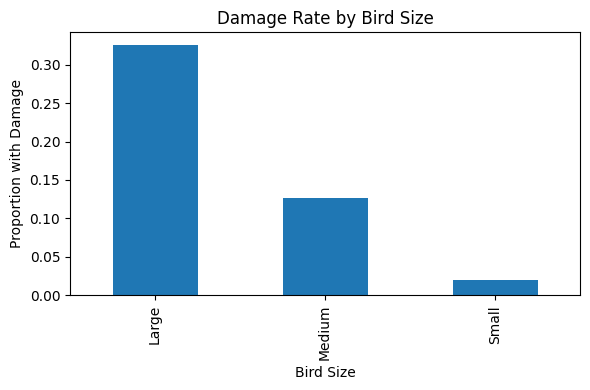

In [436]:
#note: do this before mapping size to numbers
size_damage = train_data.groupby('SIZE')['INDICATED_DAMAGE'].mean().sort_values(ascending=False)
plt.figure(figsize=(6, 4))
size_damage.plot(kind='bar')
plt.title('Damage Rate by Bird Size')
plt.ylabel('Proportion with Damage')
plt.xlabel('Bird Size')
plt.tight_layout()
plt.show()

## Damage Rate by Year

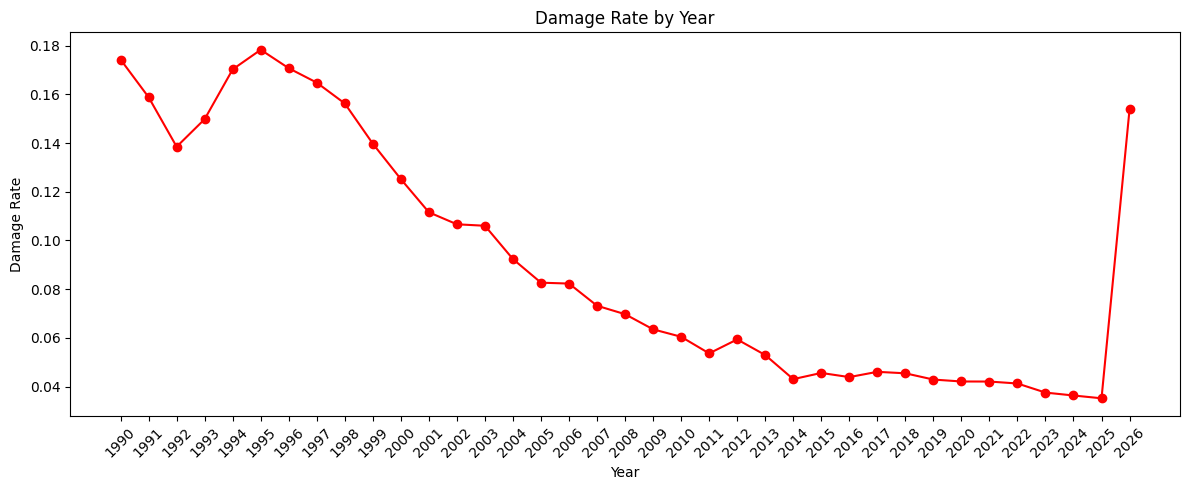

In [437]:
import matplotlib.pyplot as plt

damage_by_year = train_data.groupby("INCIDENT_YEAR")["INDICATED_DAMAGE"].mean()

plt.figure(figsize=(12, 5))
plt.plot(damage_by_year.index, damage_by_year.values, color="red", marker="o")
plt.title("Damage Rate by Year")
plt.xlabel("Year")
plt.ylabel("Damage Rate")
plt.xticks(damage_by_year.index, rotation=45)
plt.tight_layout()
plt.show()

# Handling Missing Values

We are examining the null counts after we dropped the columns and we out going to apply imputation strategies for each column. While doing this, we make sure to be careful to avoid data leakage by fitting all imputation logic on the training data only and then applying those same mappings to test data.


In [438]:
# Handling missing values
null_column_totals = train_data.isnull().sum().sort_values(ascending=False)
null_column_totals

ENG_4_POS               303909
ENROUTE_STATE           301832
PRECIPITATION           295966
ENG_3_POS               294822
SPEED                   212076
NUM_SEEN                208546
SKY                     162825
HEIGHT                  154197
TIME_OF_DAY             133971
PHASE_OF_FLIGHT         120961
DISTANCE                103303
ENG_2_POS               102509
TYPE_ENG                 87786
ENG_1_POS                87717
NUM_ENGS                 87697
AC_MASS                  87446
AC_CLASS                 87315
RUNWAY                   75585
LONGITUDE                40747
STATE                    40744
LATITUDE                 40744
SIZE                     33507
NUM_STRUCK                 647
REMAINS_COLLECTED            0
INDICATED_DAMAGE             0
WARNED                       0
REMAINS_SENT                 0
INCIDENT_DATE                0
OUT_OF_RANGE_SPECIES         0
SPECIES_ID                   0
INCIDENT_MONTH               0
AIRCRAFT                     0
OPID    

### LATITUDE and LONGITUDE Imputation

Our imputation strategy for latitude and longitude was based on the AIRPORT_ID column since LATITUDE, LONGITUDE, and AIRPORT_ID were all geographic locationrelated to geographic location, so rather than simply using a global mean or median imputation, we group records by their AIRPORT_ID and use the median coordinates per AIRPORT_ID to estimate the records LATITUDE and LONGITUDE. For airports with missing AIRPORT_ID as well, weuse a global median for imputation.


We as well were careful to use the statistics from the training data only when imputing the test data to avoid data leakage

In [439]:
# Imputation for LATITUDE and LONGITUDE
# We found during data exploration that there are some errors and inconsistencies in the data
# Some entries are formated in decimal notation, others in DMS format, and others have commas
#  which prevents us from calculating aggregates across all records

# Count the number of values in DMS format
dms_count_latitude = train_data['LATITUDE'].astype(str).str.contains("°", na=False).sum()
dms_count_longitude = train_data['LONGITUDE'].astype(str).str.contains("°", na=False).sum()
print("DMS latitude entries:", dms_count_latitude)
print("DMS longitude entries:", dms_count_longitude)

# We decided to drop records with latitude or longitude in DMS format rather than 
# converting DMS to decimal notation since they were only a small fraction of the dataset
# NOTE We only dropped rows in the training set since records should not be dropped from the test set
print("Rows before dropping invalid entries", len(train_data))
train_data = train_data[~train_data['LATITUDE'].astype(str).str.contains("°", na=False)]
train_data = train_data[~train_data['LONGITUDE'].astype(str).str.contains("°", na=False)]
print("Rows after dropping invalid entries", len(train_data))

# Ensure latitude and longitude are formatted correctly to perform aggregate functions
# by removing commas and coercing values to numeric
train_data["LATITUDE"] = train_data["LATITUDE"].astype(str).str.replace(",", "")
train_data["LONGITUDE"] = train_data["LONGITUDE"].astype(str).str.replace(",", "")
train_data["LATITUDE"] = pd.to_numeric(train_data["LATITUDE"], errors="coerce")
train_data["LONGITUDE"] = pd.to_numeric(train_data["LONGITUDE"], errors="coerce")

# Apply transformations to test data set to ensure consistency
test_data["LATITUDE"] = test_data["LATITUDE"].astype(str).str.replace(",", "")
test_data["LONGITUDE"] = test_data["LONGITUDE"].astype(str).str.replace(",", "")
test_data["LATITUDE"] = pd.to_numeric(test_data["LATITUDE"], errors="coerce")
test_data["LONGITUDE"] = pd.to_numeric(test_data["LONGITUDE"], errors="coerce")

print("Number of null values before imputation")
print("Latitude:", train_data["LATITUDE"].isnull().sum())
print("Longitude:", train_data["LONGITUDE"].isnull().sum())

# Group by airport id and impute using median
latitude_based_on_airport = train_data.groupby("AIRPORT_ID")["LATITUDE"].transform("median")
longitude_based_on_airport = train_data.groupby("AIRPORT_ID")["LONGITUDE"].transform("median")
train_data['LATITUDE'] = train_data['LATITUDE'].fillna(latitude_based_on_airport)
train_data['LONGITUDE'] = train_data['LONGITUDE'].fillna(longitude_based_on_airport)
# Impute remainders using overall median if no airport id found
train_data['LATITUDE'] = train_data['LATITUDE'].fillna(train_data["LATITUDE"].median())
train_data['LONGITUDE'] = train_data['LONGITUDE'].fillna(train_data["LONGITUDE"].median())

# Using the mapping created on the training data, use to impute test data as well
test_data['LATITUDE'] = test_data['LATITUDE'].fillna(latitude_based_on_airport)
test_data['LONGITUDE'] = test_data['LONGITUDE'].fillna(longitude_based_on_airport)
# Avoid data leakage: fill remainders with median from training data
test_data['LATITUDE'] = test_data['LATITUDE'].fillna(train_data["LATITUDE"].median())
test_data['LONGITUDE'] = test_data['LONGITUDE'].fillna(train_data["LONGITUDE"].median())


print("After imputation, check that no null values remain")
print("Latitude:", train_data["LATITUDE"].isnull().sum())
print("Longitude:", train_data["LONGITUDE"].isnull().sum())

DMS latitude entries: 4
DMS longitude entries: 1
Rows before dropping invalid entries 307178
Rows after dropping invalid entries 307174
Number of null values before imputation
Latitude: 40751
Longitude: 40746
After imputation, check that no null values remain
Latitude: 0
Longitude: 0


### STATE Imputation

Our imputation strategy for STATE is similar to LATITUDE and LONGITUDE in that we use columns related to geographic location, in this case ENROUTE_STATE, whcih provides the location during flight. If ENROUTE_STATE is also null, we use AIRPORT_ID to impute the STATE since AIRPORT_ID is associated with a fixed geographic location.

In [440]:
# If STATE is null, impute using ENROUTE_STATE, then remove ENROUTE_STATE column in the end
print("Missing states before ENROUTE_STATE imputation: ", train_data["STATE"].isnull().sum())
train_data['STATE'] = train_data['STATE'].fillna(train_data['ENROUTE_STATE'])
test_data['STATE'] = test_data['STATE'].fillna(test_data['ENROUTE_STATE'])
print("Missing states after ENROUTE_STATE imputation: ", train_data["STATE"].isnull().sum())

# Drop ENROUTE_STATE after use to reduce dimensionality
train_data = train_data.drop(columns=['ENROUTE_STATE'])
test_data = test_data.drop(columns=['ENROUTE_STATE'])

# Similar case imputation based on AIRPORT_ID since there is no null values present
print("Null entries before imputation using AIRPORT_ID grouping", train_data["STATE"].isnull().sum(), "\n")
airport_states = train_data.groupby("AIRPORT_ID")["STATE"].transform("first")
train_data["STATE"] = train_data["STATE"].fillna(airport_states)
print("Null entries in training data after imputation using AIRPORT_ID grouping", train_data["STATE"].isnull().sum(), "\n")

# Apply the same mapping to test data
airport_states = test_data.groupby("AIRPORT_ID")["STATE"].transform("first")
test_data["STATE"] = test_data["STATE"].fillna(airport_states)

# Only a small number of rows remain with null STATE after imputation
# We decided to drop these rows rather than imputing since incorrect geographic
# information could harm model
train_data = train_data.dropna(subset=["STATE"])
print("Null entries after dropping remainder", train_data["STATE"].isnull().sum(), "\n")

# Standardize STATE values since there is inconsistencies for foreign locations
# only have one value (currently FN/FGN)
train_data["STATE"] = train_data["STATE"].replace("FN", "FGN")
test_data["STATE"] = test_data["STATE"].replace("FN", "FGN")

Missing states before ENROUTE_STATE imputation:  40744
Missing states after ENROUTE_STATE imputation:  35400
Null entries before imputation using AIRPORT_ID grouping 35400 

Null entries in training data after imputation using AIRPORT_ID grouping 18 

Null entries after dropping remainder 0 



### SIZE Imputation

Initially we wanted to use similar case imputation for size based on the SPECIES_ID since there were no null values present in the column, however we found that most of the missing SIZE values were associated with  unknown species (UNKB). Since the species was unknown there was no consistent size information so similar case imputation was difficult for these.

For species that were known we imputed by finding the mode of the SIZE for that group of SPECIES_ID and otherwise as a fallback imputed with Medium.

In [441]:
# Similar Case imputation for SIZE based on SPECIES_ID since we have no null values there
# However we found that this did not work, each null entry in SIZE corresponded with Unknown 
# Bird SPECIES (UNKB SPECIES_ID) which all contained null for size
size = train_data["SIZE"].isnull()
species_id = train_data["SPECIES_ID"].isnull()
shared_null_2 = (size & species_id).sum()
print("Number of missing values in SIZE: ", size.sum())
print("Missing values in SPECIES_ID: ", species_id.sum())
print("Rows where both values are missing: ", shared_null_2)

# Impute size using SPECIES_ID
print("Null entries before SPECIES_ID imputation", train_data["SIZE"].isnull().sum(), "\n")
species_sizes = (train_data.dropna(subset=["SIZE"]).groupby("SPECIES_ID")["SIZE"].agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None))
train_data["SIZE"] = train_data["SIZE"].fillna(train_data["SPECIES_ID"].map(species_sizes))
# Since we are computing the mode, we apply the same mapping from the training data to the test data to avoid data leakage
test_data["SIZE"] = test_data["SIZE"].fillna(test_data["SPECIES_ID"].map(species_sizes))
print("Null entries after SPECIES_ID imputation", train_data["SIZE"].isnull().sum(), "\n")

# Choose to impute the remaining null entries in SIZE with medium
train_data["SIZE"] = train_data["SIZE"].fillna("Medium")
test_data["SIZE"] = test_data["SIZE"].fillna("Medium")
print("Null entries after imputation", train_data["SIZE"].isnull().sum(), "\n")

Number of missing values in SIZE:  33507
Missing values in SPECIES_ID:  0
Rows where both values are missing:  0
Null entries before SPECIES_ID imputation 33507 

Null entries after SPECIES_ID imputation 33507 

Null entries after imputation 0 



### RUNWAY Imputation

Looking through the documentation, we found that null values in RUNWAY column indicate that the aircraft was airborne at the time of impact. Based on this, we replace null values with "AIRBORNE" to preserve the information rather than treating them as unknown.

In [442]:
# Impute null values in RUNWAY
# RUNWAY - Runway designation where the strike occurred (blank if airborne).
# Null values exist but they have meaning (airborne)
print("Null entries before imputation", train_data["RUNWAY"].isnull().sum(), "\n")
train_data["RUNWAY"] = train_data["RUNWAY"].fillna("AIRBORNE")
test_data["RUNWAY"] = test_data["RUNWAY"].fillna("AIRBORNE")
print("Null entries after imputation", train_data["RUNWAY"].isnull().sum(), "\n")

Null entries before imputation 75568 

Null entries after imputation 0 



### AC_CLASS Imputation

Missing values in AC_CLASS represent unknown aircraft classifications. We imputed using a new category "U" to preserve information that the class is unknown

In [443]:
# AC_CLASS - Aircraft class (A = airplane, B = helicopter, C = glider, J = ultralight, Y = other).
print("Null entries before imputation", train_data["AC_CLASS"].isnull().sum(), "\n")
ac_class_impute = "U"
train_data["AC_CLASS"] = train_data["AC_CLASS"].fillna(ac_class_impute)
test_data["AC_CLASS"] = test_data["AC_CLASS"].fillna(ac_class_impute)
print("Null entries after imputation", train_data["AC_CLASS"].isnull().sum(), "\n")

Null entries before imputation 87315 

Null entries after imputation 0 



### AC_MASS Imputation

We imputed AC_MASS using the mode, to present the most common mass in any null entries, using the same value to impute bonth the training set and the test set to avoid data leakage

In [444]:
# AC_MASS - Aircraft weight class (1 = 2,250 kg or less through 5 = above 272,000 kg).
# Impute using mode
print("Null entries before imputation", train_data["AC_MASS"].isnull().sum(), "\n")
ac_mass_impute = train_data["AC_MASS"].mode()[0]
train_data["AC_MASS"] = train_data["AC_MASS"].fillna(ac_mass_impute)
test_data["AC_MASS"] = test_data["AC_MASS"].fillna(ac_mass_impute)
print("Null entries after imputation", train_data["AC_MASS"].isnull().sum(), "\n")


Null entries before imputation 87446 

Null entries after imputation 0 



### NUM_ENGS Imputation

We imputed NUM_ENGS using the median rather than the mean to prevent being influenced by outliers

In [445]:
# NUM_ENGS - Number of engines on the aircraft.
# Impute using median
print("Null entries before imputation", train_data["NUM_ENGS"].isnull().sum(), "\n")
num_engs_impute = train_data["NUM_ENGS"].median()
train_data["NUM_ENGS"] = train_data["NUM_ENGS"].fillna(num_engs_impute)
test_data["NUM_ENGS"] = test_data["NUM_ENGS"].fillna(num_engs_impute)
print("Null entries after imputation", train_data["NUM_ENGS"].isnull().sum(), "\n")

Null entries before imputation 87697 

Null entries after imputation 0 



### ENG_1_POS Imputation

ENG_1_POS is the position of the engine on the aircraft, we impute missing values using the mode, which is the most frequently occurring position

In [446]:
# ENG_1_POS - The mounting position of engine 1 on the aircraft.
print("Null entries before imputation", train_data["ENG_1_POS"].isnull().sum(), "\n")
eng_1_pos_impute = train_data["ENG_1_POS"].mode()
train_data["ENG_1_POS"] = train_data["ENG_1_POS"].fillna(eng_1_pos_impute)
# Use mode of training data to avoid data leakage
test_data["ENG_1_POS"] = test_data["ENG_1_POS"].fillna(eng_1_pos_impute)
print("Null entries after imputation", train_data["ENG_1_POS"].isnull().sum(), "\n")

Null entries before imputation 87717 

Null entries after imputation 87717 



### TYPE_ENG Imputation

We impute missing values in TYPE_ENG with "U" (unknown)

In [447]:
# TYPE_ENG - The type of engine.
# Fill missing values with U for unknown
print("Null entries before imputation", train_data["TYPE_ENG"].isnull().sum(), "\n")
train_data["TYPE_ENG"] = train_data["TYPE_ENG"].fillna("U")
test_data["TYPE_ENG"] = test_data["TYPE_ENG"].fillna("U")
print("Null entries after imputation", train_data["TYPE_ENG"].isnull().sum(), "\n")

Null entries before imputation 87786 

Null entries after imputation 0 



### PRECIPITATION Imputation

Missing values in PRECIPITATION are filled with "None" based on documentation since null indicates that there was no precipitation

In [448]:
# PRECIPITATION
# Fill missing values with None based on Kaggle column description
print("Null entries before imputation", train_data["PRECIPITATION"].isnull().sum(), "\n")
train_data["PRECIPITATION"] = train_data["PRECIPITATION"].fillna("None")
train_data["PRECIPITATION"].value_counts()

test_data["PRECIPITATION"] = test_data["PRECIPITATION"].fillna("None")
test_data["PRECIPITATION"].value_counts()
print("Null entries after imputation", train_data["PRECIPITATION"].isnull().sum(), "\n")

Null entries before imputation 295946 

Null entries after imputation 0 



### PHASE_OF_FLIGHT Imputation

We impute missing PHASE_OF_FLIGHT values with "UNKNOWN"

In [449]:
# Imputation for PHASE_OF_FLIGHT
# Possible Values: Approach, Climb, Descent, En Route, Landing Roll, Parked, Take-off Run, Taxi
print("Null entries before imputation", train_data["PHASE_OF_FLIGHT"].isnull().sum(), "\n")
print(train_data["PHASE_OF_FLIGHT"].value_counts())
train_data["PHASE_OF_FLIGHT"] = train_data["PHASE_OF_FLIGHT"].fillna("UNKNOWN")
test_data["PHASE_OF_FLIGHT"] = test_data["PHASE_OF_FLIGHT"].fillna("UNKNOWN")
print("Null entries after imputation", train_data["RUNWAY"].isnull().sum(), "\n")


Null entries before imputation 120961 

PHASE_OF_FLIGHT
Approach        79157
Landing Roll    33635
Take-off Run    31006
Climb           27444
En Route         5600
Departure        3569
Descent          2630
Local            1368
Arrival           958
Taxi              717
Parked            102
Unknown             9
Name: count, dtype: int64
Null entries after imputation 0 



### AC_MASS Imputation

We impute AC_MASS using the mode from the training set to avoid data leakage.

In [450]:
# Impute AC Mass using mode
print("Null entries before imputation", train_data["AC_MASS"].isnull().sum(), "\n")
print(train_data["AC_MASS"].value_counts())
train_data["AC_MASS"] = train_data["AC_MASS"].fillna(train_data["AC_MASS"].mode()[0])
test_data["AC_MASS"] = test_data["AC_MASS"].fillna(train_data["AC_MASS"].mode()[0])
print("Null entries after imputation", train_data["AC_MASS"].isnull().sum(), "\n")



Null entries before imputation 0 

AC_MASS
4.0    244700
3.0     33443
2.0     13442
1.0     13091
5.0      2480
Name: count, dtype: int64
Null entries after imputation 0 



### NUM_STRUCK Imputation

We impute NUM_STRUCK with "UNKNOWN" to indicate that this was unreported

In [451]:
# Impute NUM_STRUCK
print("Null entries after imputation", train_data["NUM_STRUCK"].isnull().sum(), "\n")
train_data["NUM_STRUCK"] = train_data["NUM_STRUCK"].fillna("UNKNOWN")
test_data["NUM_STRUCK"] = test_data["NUM_STRUCK"].fillna("UNKNOWN")
print(train_data["NUM_STRUCK"].value_counts())
print("Null entries after imputation", train_data["NUM_STRUCK"].isnull().sum(), "\n")


Null entries after imputation 640 

NUM_STRUCK
1                273266
10-Feb            31697
11-100             1502
UNKNOWN             640
More than 100        51
Name: count, dtype: int64
Null entries after imputation 0 



### HEIGHT Imputation

We imputed HEIGHT based on the PHASE_OF_FLIGHT that the aircraft is in. If the aircraft is in ground phases (Taxi, Parked, Landing Roll), HEIGHT is set to 0. Otherwise, missing values are filled using the median height to preserve realistic flight conditions while avoiding skew from outliers.

In [452]:
# Impute HEIGHT
print("Null entries after imputation", train_data["HEIGHT"].isnull().sum(), "\n")
print(train_data["HEIGHT"].value_counts())
# If HEIGHT is null and phase is either Parked, Taxi, or Landing Roll, impute with 0
height_0_phases = ["Parked", "Taxi", "Landing Roll"]
# Create a mask to identify flights in these phases
train_mask = train_data["PHASE_OF_FLIGHT"].isin(height_0_phases)
test_mask = test_data["PHASE_OF_FLIGHT"].isin(height_0_phases)
train_data.loc[train_mask & train_data["HEIGHT"].isnull(), "HEIGHT"] = 0
test_data.loc[test_mask & test_data["HEIGHT"].isnull(), "HEIGHT"] = 0

# Otherwise impute with median FROM TRAINING DATA (prevent data leakage)
height_to_impute = train_data["HEIGHT"].median()
train_data.loc[~train_mask, "HEIGHT"] = train_data.loc[~train_mask, "HEIGHT"].fillna(height_to_impute)
test_data.loc[~test_mask, "HEIGHT"] = test_data.loc[~test_mask, "HEIGHT"].fillna(height_to_impute)

print("Null entries after imputation", train_data["HEIGHT"].isnull().sum(), "\n")

Null entries after imputation 154195 

HEIGHT
0.0       65563
100.0      6528
50.0       5742
500.0      5307
1000.0     5183
          ...  
1525.0        1
1029.0        1
2231.0        1
7350.0        1
990.0         1
Name: count, Length: 708, dtype: int64
Null entries after imputation 0 



### SPEED Imputation

We decided to impute SPEED based on the TYPE_ENG of the plane since planes with similar engines would likely have similar speed distributions. After grouping, we used the median of the SPEED for a given engine type in the training data which prevented data leakage. The remaining missing values were filled using the global median of the trainig data

In [453]:
# Impute SPEED: group data based on the type of engine that the aircraft uses
# Since similar engines will likely have similar speeds
# Then use the median of the groupings
print("Null entries before imputation", train_data["SPEED"].isnull().sum(), "\n")
speed_to_impute = train_data.groupby("TYPE_ENG")["SPEED"].transform("median")
train_data["SPEED"] = train_data["SPEED"].fillna(speed_to_impute)
test_data["SPEED"] = test_data["SPEED"].fillna(speed_to_impute)
# otherwise impute the rest with overall median
train_data["SPEED"] = train_data["SPEED"].fillna(train_data["SPEED"].median())
test_data["SPEED"] = test_data["SPEED"].fillna(train_data["SPEED"].median())
print("Null entries after imputation", train_data["SPEED"].isnull().sum(), "\n")

Null entries before imputation 212068 

Null entries after imputation 0 



### SKY Imputation

We impute missing values in SKY with "Unknown"

In [454]:
# Impute SKY with unknown
print("Null entries before imputation", train_data["SKY"].isnull().sum(), "\n")
print(train_data["SKY"].value_counts())
train_data["SKY"] = train_data["SKY"].fillna("Unknown")
test_data["SKY"] = test_data["SKY"].fillna("Unknown")
print("Null entries after imputation", train_data["SKY"].isnull().sum(), "\n")

Null entries before imputation 162812 

SKY
No Cloud      70572
Some Cloud    49702
Overcast      24070
Name: count, dtype: int64
Null entries after imputation 0 



### TIME_OF_DAY Imputation

We impute missing values in TIME_OF_DAY with "Unknown" to show that time information was not recorded

In [455]:
print("Null entries after imputation", train_data["TIME_OF_DAY"].isnull().sum(), "\n")
print(train_data["TIME_OF_DAY"].value_counts())
train_data["TIME_OF_DAY"] = train_data["TIME_OF_DAY"].fillna("Unknown")
test_data["TIME_OF_DAY"] = test_data["TIME_OF_DAY"].fillna("Unknown")
print("Null entries after imputation", train_data["TIME_OF_DAY"].isnull().sum(), "\n")


Null entries after imputation 133965 

TIME_OF_DAY
Day      105748
Night     53906
Dusk       7621
Dawn       5916
Name: count, dtype: int64
Null entries after imputation 0 



### DISTANCE Imputation

We impute missing DISTANCE by grouping based on PHASE_OF_FLIGHT since the distance from the airport is dependent on flight phase. Once we group by phase of flight, we find the median values within each group to determine distance. Any remaining missing values are filled with the global median. The median calculations were done using trianing data to avoid data leakage

In [456]:
# Impute DISTANCE based on phase of flight. Phase of flight will determine how far an aircraft may be
# Group based on phase of flight and impute using median distance within that phase

distance_map = train_data.groupby("PHASE_OF_FLIGHT")["DISTANCE"].median()
train_data["DISTANCE"] = train_data["DISTANCE"].fillna(train_data["PHASE_OF_FLIGHT"].map(distance_map))
test_data["DISTANCE"] = test_data["DISTANCE"].fillna(test_data["PHASE_OF_FLIGHT"].map(distance_map))
# fill any remaining nulls
train_data["DISTANCE"] = train_data["DISTANCE"].fillna(train_data["DISTANCE"].median())
test_data["DISTANCE"] = test_data["DISTANCE"].fillna(train_data["DISTANCE"].median())

In [457]:
# Check to see if number of engines and missing values in END_X_POS correlate
train_data[["NUM_ENGS", "ENG_1_POS", "ENG_2_POS", "ENG_3_POS", "ENG_4_POS"]].head(20)
# Findings: Number of engines reported TYPICALLY (not always) corresponds with the number of non null values in ENG_1_POS.
# if only 2 engines, END_1_POS and ENG_2_POS equal

,NUM_ENGS,ENG_1_POS,ENG_2_POS,ENG_3_POS,ENG_4_POS
0,3.0,5.0,6.0,5.0,NaN
1,3.0,1.0,6.0,1.0,NaN
2,2.0,1.0,1.0,NaN,NaN
3,2.0,NaN,NaN,NaN,NaN
4,2.0,1.0,1.0,NaN,NaN
5,2.0,1.0,1.0,NaN,NaN
6,2.0,1.0,1.0,NaN,NaN
7,2.0,5.0,5.0,NaN,NaN
8,2.0,1.0,1.0,NaN,NaN
9,2.0,1.0,1.0,NaN,NaN


In [458]:
# Impute NUM_SEEN by first normalizing the data to be only numeric
num_seen_values = {
    "1": 1,
    "10-Feb": 5,
    "11-100": 50,
    "More than 100": 150
}

# Map categorical values to numeric representations
train_data["NUM_SEEN"] = train_data["NUM_SEEN"].map(num_seen_values)
test_data["NUM_SEEN"] = test_data["NUM_SEEN"].map(num_seen_values)

In [459]:
# Check that all values have been correctly filled in
# Handling missing values
null_column_totals = train_data.isnull().sum().sort_values(ascending=False)
null_column_totals

ENG_4_POS               303888
ENG_3_POS               294801
NUM_SEEN                208542
ENG_2_POS               102492
ENG_1_POS                87717
INDICATED_DAMAGE             0
PRECIPITATION                0
HEIGHT                       0
SPEED                        0
DISTANCE                     0
SKY                          0
SPECIES_ID                   0
SIZE                         0
PHASE_OF_FLIGHT              0
REMAINS_COLLECTED            0
REMAINS_SENT                 0
WARNED                       0
NUM_STRUCK                   0
OUT_OF_RANGE_SPECIES         0
INCIDENT_DATE                0
INCIDENT_MONTH               0
NUM_ENGS                     0
TYPE_ENG                     0
AC_MASS                      0
AC_CLASS                     0
AIRCRAFT                     0
OPID                         0
STATE                        0
RUNWAY                       0
LONGITUDE                    0
LATITUDE                     0
AIRPORT_ID                   0
TIME_OF_

## Feature Engineering

### SEVERITY Feature
We created a new feature, SEVERITY by combining SIZE (bird size) and NUM_STRUCK (number of birds struck) to determine how severe the impact on the aircraft was. Since both features are categorical, we first mapped them to be numeric values while preserving their ordinal relationship. We then computed SEVERITY by multiplying these two features. The reasoning behind this is that larger birds and higher quantities would cause more risk of damage. Any missing values are imputed using the median of the training dataset to avoid data leakage.

In [460]:
# Create feature based on NUM_STRUCK and SIZE
# SIZE is a string value; map to numerical values to calculate severity of impact by multiplying SIZE * NUM_STRUCK
train_data["SIZE"] = train_data["SIZE"].map({
    "Small": 1,
    "Medium": 2,
    "Large": 3
})
# NUM_STRUCK is a range string value, map to numerical value to reflect impact
train_data["NUM_STRUCK"] = train_data["NUM_STRUCK"].map({
    "1": 1,
    "10-Feb": 5,
    "11-100": 10,
    "More than 100": 100
})
# Calculate severity of impact by multiplying SIZE_NUM * NUM_STRUCK
train_data["SEVERITY"] = train_data["NUM_STRUCK"] * train_data["SIZE"]
# Impute any null entries with the median
train_data["SEVERITY"] = train_data["SEVERITY"].fillna(train_data["SEVERITY"].median())


test_data["SIZE"] = test_data["SIZE"].map({
    "Small": 1,
    "Medium": 2,
    "Large": 3
})
# NUM_STRUCK is a range string value, map to numerical value to reflect impact
test_data["NUM_STRUCK"] = test_data["NUM_STRUCK"].map({
    "1": 1,
    "10-Feb": 5,
    "11-100": 10,
    "More than 100": 100
})
# Calculate severity of impact by multiplying SIZE_NUM * NUM_STRUCK
test_data["SEVERITY"] = test_data["NUM_STRUCK"] * test_data["SIZE"]
# Impute using median of training data to avoid data leakage
test_data["SEVERITY"] = test_data["SEVERITY"].fillna(train_data["SEVERITY"].median())
print("Null entries after creation", train_data["SEVERITY"].isnull().sum(), "\n")

Null entries after creation 0 



### SEASON Feature

We created a new SEASON feature from INCIDENT_MONTH to show whether the bird impacts had any seasonal patterns. Since birds migrate throughout the year, this can influence the likelihood and severity of aircraft strikes. We group the months into Winter, Spring, Summer, and Fall to create a more broad grouping rather than incident month

In [461]:
# Create a feature based on season of impact
# 1: Winter (Dec–Feb), 2: Spring (Mar–May), 3: Summer (Jun–Aug), 4: Fall (Sep–Nov)
train_data["SEASON"] = train_data["INCIDENT_MONTH"].apply(lambda x: (x % 12 // 3) + 1)

test_data["SEASON"] = test_data["INCIDENT_MONTH"].apply(lambda x: (x % 12 // 3) + 1)
print("Null entries after creation", train_data["SEASON"].isnull().sum(), "\n")

Null entries after creation 0 



### RISK_SCORE Feature
We converted the RUNWAY feature since it had high data sparsity by extracting whether the aircraft was airborne or not. 
We also created features based on the aircraft speed and height to determine impact energy, critical flight phases, ad used aircraft characteristics, and environmental conditions such as visibility and precipitation to factor into our RISK_SCORE feature, which determines the strike's severity by risk conditions.

In [462]:
# Create feature of whether the aircraft was airborne or not depending on the value of RUNWAY
# RUNWAY has MANY different values (over 1000)
print(train_data["RUNWAY"].value_counts())
train_data["IS_AIRBORNE"] = (train_data["RUNWAY"] == "AIRBORNE").astype(int)
test_data["IS_AIRBORNE"] = (test_data["RUNWAY"] == "AIRBORNE").astype(int)

#new features

# Kinetic energy proxy: higher speed + higher altitude = more damaging strike
train_data["HEIGHT_SPEED"] = train_data["HEIGHT"] * train_data["SPEED"]
test_data["HEIGHT_SPEED"] = test_data["HEIGHT"] * test_data["SPEED"]

# High-risk flight phases where strikes are most likely to cause damage
critical_phases = ["Approach", "Climb", "Take-off Run", "Descent"]
train_data["IS_CRITICAL_PHASE"] = train_data["PHASE_OF_FLIGHT"].isin(critical_phases).astype(int)
test_data["IS_CRITICAL_PHASE"] = test_data["PHASE_OF_FLIGHT"].isin(critical_phases).astype(int)

# Multi-engine aircraft may sustain less damage from a single engine strike
train_data["IS_MULTI_ENGINE"] = (train_data["NUM_ENGS"] > 1).astype(int)
test_data["IS_MULTI_ENGINE"] = (test_data["NUM_ENGS"] > 1).astype(int)

# Heavy aircraft tend to be more resilient to wildlife strikes
train_data["IS_HEAVY"] = (train_data["AC_MASS"] >= 4).astype(int)
test_data["IS_HEAVY"] = (test_data["AC_MASS"] >= 4).astype(int)

# Bad visibility conditions increase strike severity risk
bad_sky = ["Overcast", "Some Cloud"]
train_data["BAD_VISIBILITY"] = train_data["SKY"].isin(bad_sky).astype(int)
test_data["BAD_VISIBILITY"] = test_data["SKY"].isin(bad_sky).astype(int)

# Strikes during precipitation are likely more severe
train_data["HAS_PRECIP"] = (train_data["PRECIPITATION"] != "None").astype(int)
test_data["HAS_PRECIP"] = (test_data["PRECIPITATION"] != "None").astype(int)

# Combined risk score: severity scaled by whether conditions were dangerous
train_data["RISK_SCORE"] = train_data["SEVERITY"] * (train_data["IS_CRITICAL_PHASE"] + train_data["BAD_VISIBILITY"] + train_data["HAS_PRECIP"] + 1)
test_data["RISK_SCORE"] = test_data["SEVERITY"] * (test_data["IS_CRITICAL_PHASE"] + test_data["BAD_VISIBILITY"] + test_data["HAS_PRECIP"] + 1)

print("New features added successfully")
train_data[["HEIGHT_SPEED", "IS_CRITICAL_PHASE", "IS_MULTI_ENGINE", "IS_HEAVY", "BAD_VISIBILITY", "HAS_PRECIP", "RISK_SCORE"]].head()

# Drop RUNWAY
train_data = train_data.drop(columns=["RUNWAY"])
test_data = test_data.drop(columns=["RUNWAY"])

RUNWAY
AIRBORNE             75568
27                    4180
22L                   4018
17R                   3993
22                    3794
                     ...  
L1                       1
19 R                     1
TWY C @ RWY 13/31        1
18R/26L                  1
TWY K6                   1
Name: count, Length: 1363, dtype: int64
New features added successfully


In [463]:
# Get list of columns
train_data.columns

Index(['INCIDENT_DATE', 'INCIDENT_MONTH', 'INCIDENT_YEAR', 'TIME_OF_DAY',
       'AIRPORT_ID', 'LATITUDE', 'LONGITUDE', 'STATE', 'OPID', 'AIRCRAFT',
       'AC_CLASS', 'AC_MASS', 'TYPE_ENG', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS',
       'ENG_3_POS', 'ENG_4_POS', 'PHASE_OF_FLIGHT', 'HEIGHT', 'SPEED',
       'DISTANCE', 'SKY', 'PRECIPITATION', 'SPECIES_ID',
       'OUT_OF_RANGE_SPECIES', 'REMAINS_COLLECTED', 'REMAINS_SENT', 'WARNED',
       'NUM_SEEN', 'NUM_STRUCK', 'SIZE', 'INDICATED_DAMAGE',
       'YEARS_SINCE_START', 'SEVERITY', 'SEASON', 'IS_AIRBORNE',
       'HEIGHT_SPEED', 'IS_CRITICAL_PHASE', 'IS_MULTI_ENGINE', 'IS_HEAVY',
       'BAD_VISIBILITY', 'HAS_PRECIP', 'RISK_SCORE'],
      dtype='object')

In [464]:
train_data = train_data.drop(columns=["INCIDENT_DATE"])
test_data = test_data.drop(columns=["INCIDENT_DATE"])

# Creating the Model

In [465]:
# Using CatBoost: no need to use one hot encoding or frequency encoding due to categorical variable handling by model
categorical_cols = ['TIME_OF_DAY', 'AIRPORT_ID', 'STATE', 'OPID', 
                    'AIRCRAFT', 'AC_CLASS', 'TYPE_ENG', 
                    'PHASE_OF_FLIGHT', 'PRECIPITATION', 
                    'SPECIES_ID', 'SKY', 'WARNED']

for col in categorical_cols:
    train_data[col] = train_data[col].fillna("Unknown").astype(str)
    test_data[col] = test_data[col].fillna("Unknown").astype(str)


In [ ]:
# Import required libraries for modeling, preprocessing, and evaluation
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
import numpy as np

In [ ]:
# Split features and target variable, X_test will be used for final predictions
X = train_data.drop("INDICATED_DAMAGE", axis=1)
y = train_data["INDICATED_DAMAGE"]
X_test = test_data.copy()


# Label encoding for LightGBM and XGBoost. This is needed because these models cannot handle
# categorical string columns directly like CatBoost can, so we convert categorical values into integer
# labels. We also handle unseen categories in test data by assigning a default value of -1.
X_lgbm = X.copy()
X_test_lgbm = X_test.copy()
encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    # This will fit the encoder on the training data and transform
    X_lgbm[col] = le.fit_transform(X[col].astype(str))
    # This stores the encoder for reuse on the test data
    encoders[col] = le
    # This transforms the test data, mapping unseen values safely to -1
    X_test_lgbm[col] = X_test[col].astype(str).map(
        lambda val, le=le: le.transform([val])[0] if val in le.classes_ else -1
    )

In [ ]:
# These are the model hyperparameters. We pre tuned the parameters for each model
# to improve performance and handle imbalance using Optuna.


# CatBoost parameters, handling the categorical features
cat_params = {
    "iterations": 1194,
    "depth": 7,
    "learning_rate": 0.018730521653235296,
    "l2_leaf_reg": 7.143298095269057,
    "bagging_temperature": 0.6306166028728538,
    "min_data_in_leaf": 27,
    "loss_function": "Logloss",
    "eval_metric": "AUC",
    "auto_class_weights": "Balanced",
    "verbose": 0,
    "random_seed": 42
}


# LighGBM parameters
lgbm_params = {
    "n_estimators": 2000,
    "learning_rate": 0.02,
    "num_leaves": 31,
    "min_child_samples": 20,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.1,
    "reg_lambda": 1.0,
    "class_weight": "balanced",
    "random_state": 42,
    "verbose": -1
}


# XGBoost parameters
# Used scale_pos_weight adjusts for class imbalance based on the label distribution
scale_pos_weight = (y == 0).sum() / (y == 1).sum()
xgb_params = {
    "n_estimators": 1000,
    "learning_rate": 0.05,
    "max_depth": 6,
    "scale_pos_weight": scale_pos_weight,
    "eval_metric": "logloss",
    "random_state": 42,
    "verbosity": 0
}


In [ ]:
# Need to initialize out of fold predictions. These will store validation predictions
# for each training sample and are later used to train the meta-model when doing stacking
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


oof_cat  = np.zeros(len(X))
oof_lgbm = np.zeros(len(X))
oof_xgb  = np.zeros(len(X))


# Will store the averaged test predictions across folds
test_cat  = np.zeros(len(X_test))
test_lgbm = np.zeros(len(X_test))
test_xgb  = np.zeros(len(X_test))


# We will perform a 5-Fold Cross Validation and for each fold, we will train on
# 4 folds and validate using 1 fold. We store these predictions. This will avoid
# data leakage for stacking.
print("Training base models with 5-fold CV...")
for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
   
    print(f"  Fold {fold+1}/5")
    # For each fold, we split the data into training and validation sets
    X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
    X_tr_lgbm, X_val_lgbm = X_lgbm.iloc[train_idx], X_lgbm.iloc[val_idx]
    y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]


    # CatBoost
    cat = CatBoostClassifier(**cat_params)
    cat.fit(X_tr, y_tr, cat_features=categorical_cols)
    oof_cat[val_idx] = cat.predict_proba(X_val)[:, 1] # stores the validation predictions
    test_cat += cat.predict_proba(X_test)[:, 1] / kf.n_splits # average predictions for test set


    # LightGBM
    lgbm = LGBMClassifier(**lgbm_params)
    lgbm.fit(X_tr_lgbm, y_tr)
    oof_lgbm[val_idx] = lgbm.predict_proba(X_val_lgbm)[:, 1]
    test_lgbm += lgbm.predict_proba(X_test_lgbm)[:, 1] / kf.n_splits


    # XGBoost
    xgb = XGBClassifier(**xgb_params)
    xgb.fit(X_tr_lgbm, y_tr)  # uses encoded features
    oof_xgb[val_idx] = xgb.predict_proba(X_val_lgbm)[:, 1]
    test_xgb += xgb.predict_proba(X_test_lgbm)[:, 1] / kf.n_splits


print("\nBase model OOF balanced accuracy:")
print(f"  CatBoost : {balanced_accuracy_score(y, (oof_cat  >= 0.5).astype(int)):.4f}")
print(f"  LightGBM : {balanced_accuracy_score(y, (oof_lgbm >= 0.5).astype(int)):.4f}")
print(f"  XGBoost  : {balanced_accuracy_score(y, (oof_xgb  >= 0.5).astype(int)):.4f}")


In [ ]:
# This is the meta model (Stacking). Here, we combine predictions from base models as
# features and use logistic regression to learn how to best combine them.
meta_X_train = np.column_stack([oof_cat, oof_lgbm, oof_xgb])
meta_X_test  = np.column_stack([test_cat, test_lgbm, test_xgb])


# You need to standardize the meta features as this is important for linear models
scaler = StandardScaler()
meta_X_train = scaler.fit_transform(meta_X_train)
meta_X_test  = scaler.transform(meta_X_test)


# Train the meta model
meta_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
meta_model.fit(meta_X_train, y)


# We chose to add threshold tuning so that instead of the default of 0.5, we find the
# optimal threshold for the best balanced accuracy.
meta_oof_probs = meta_model.predict_proba(meta_X_train)[:, 1]
best_thresh, best_score = 0.5, 0
for thresh in np.arange(0.3, 0.7, 0.01):
    preds = (meta_oof_probs >= thresh).astype(int)
    score = balanced_accuracy_score(y, preds)
    if score > best_score:
        best_score = score
        best_thresh = thresh


print(f"\nMeta-model OOF Balanced Accuracy: {best_score:.4f}, Best threshold: {best_thresh:.2f}")


In [ ]:
# Here, find the final predictions on the test data and apply the optimized threshold
# found earlier to generate the submission.csv file


final_probs = meta_model.predict_proba(meta_X_test)[:, 1]
final_preds = (final_probs >= best_thresh).astype(int)


test_dataset = pd.read_csv("test.csv")
submission = pd.DataFrame({
    "INDEX_NR": test_dataset["INDEX_NR"],
    "INDICATED_DAMAGE": final_preds
})
submission.to_csv("submission.csv", index=False)
print("\nSubmission saved!")
print(submission["INDICATED_DAMAGE"].value_counts())

Initially we tried implementation using only a CatBoostClassifier with fixed parameters but realized that using only a single model was insufficient as compared to other methods such as stacking.

In [ ]:
# import numpy as np

# from catboost import CatBoostClassifier, Pool
# from sklearn.metrics import balanced_accuracy_score
# from sklearn.model_selection import train_test_split
# from sklearn.model_selection import StratifiedKFold


# # initialize data
# X = train_data.drop("INDICATED_DAMAGE", axis=1)
# y = train_data["INDICATED_DAMAGE"]
# X_test = test_data.copy()

# # Cross validation
# kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# scores = []
# for fold, (train_idx, val_idx) in enumerate(kf.split(X, y)):
#     X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
#     y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

#     model = CatBoostClassifier(iterations=1000,
#                             depth=6,
#                             learning_rate=0.05,
#                             loss_function='Logloss',
#                             eval_metric='AUC',
#                             auto_class_weights = "Balanced",
#                             verbose=100)
#     # train the model
#     model.fit(X_train, y_train, cat_features=categorical_cols, eval_set=(X_val, y_val), use_best_model=True)
#     val_predictions = model.predict(X_val)
#     score = balanced_accuracy_score(y_val, val_predictions)
#     print(f"Fold {fold}: {score:.4f}")
#     scores.append(score)

# print("\nMean CV Balanced Accuracy:", np.mean(scores))

# # X_train, X_val, y_train, y_val = train_test_split(
# #     X, y,
# #     test_size=0.2,
# #     random_state=42,
# #     stratify=y
# # )

# # make the prediction on the validation set using the resulting model
# # val_probabilities = model.predict_proba(X_val)[:, 1]
# # val_predictions = (val_probabilities >= 0.5).astype(int)
# # score = balanced_accuracy_score(y_val, val_predictions)
# # print(f"Balanced Accuracy: {score:.4f}")

# # Separately generate submission predictions on test set
# test_probabilities = model.predict_proba(X_test)[:, 1]
# test_predictions = (test_probabilities >= 0.5).astype(int)

In [ ]:
# # Create final model using entire training set
# import numpy as np

# from catboost import CatBoostClassifier, Pool
# from sklearn.metrics import balanced_accuracy_score
# from sklearn.model_selection import train_test_split
# from sklearn.model_selection import StratifiedKFold


# # initialize data
# X = train_data.drop("INDICATED_DAMAGE", axis=1)
# y = train_data["INDICATED_DAMAGE"]
# X_test = test_data.copy()

# model = CatBoostClassifier(iterations=1000,
#                         depth=6,
#                         learning_rate=0.05,
#                         loss_function='Logloss',
#                         eval_metric='AUC',
#                         auto_class_weights = "Balanced",
#                         verbose=100)
# # train the model on the entire training dataset
# model.fit(X, y, cat_features=categorical_cols)
# # Generate predictions for test set
# test_probabilities = model.predict_proba(X_test)[:, 1]
# test_predictions = (test_probabilities >= 0.5).astype(int)

## Handling Categorical Features 
### One Hot Encoding and Handling High Cardinality Categorical Features with Frequency Encoding

We originally experimented with encoding our categorical features using one-hot encoding and frequency encoding.

For one-hot encoding because of the large number of categorical columns and their high cardinality, this significantly increased the dimensionality of the dataset and harmed the data model.

To combat this we tried frequency encoding where each categorical variable value counts the frequency in the dataset. Compared to one-hot encoding the dimensionality was less, but still significantly large which would harm the data model. 

We ended up deciding against both encoding and used CatBoost which handles categorical features without having to encode by identifying the columns that are to be handled categorically.

In [ ]:
# # need to one hot encode categorical variables
# # categorical_columns =['NUM_STRUCK', 'TIME_OF_DAY', 'AIRPORT_ID', 'RUNWAY', 'STATE', 'FAAREGION', 'LOCATION', 'OPID', 'AIRCRAFT', 'AC_CLASS', 'TYPE_ENG', 'PHASE_OF_FLIGHT', 'SKY', 'SPECIES_ID', 'WARNED', 'SIZE', 'ENROUTE_STATE', 'SOURCE', 'PERSON']
# # categorical_columns =['AIRPORT_ID', 'RUNWAY', 'STATE', 'OPID', 'AIRCRAFT', 'AC_CLASS', 'TYPE_ENG', 'SPECIES_ID', 'PRECIPITATION']
# categorical_columns =['AC_CLASS', 'TYPE_ENG', 'PRECIPITATION']
# train_data = pd.get_dummies(train_data, columns = categorical_columns, drop_first=True)

# test_data = pd.get_dummies(test_data, columns = categorical_columns, drop_first=True)


# # WHAT TO ONE HOT ENCODE
# # NUM_STRUCK, TIME_OF_DAY, AIRPORT_ID, RUNWAY, STATE, FAAREGION, LOCATION, OPID, AIRCRAFT, AC_CLASS, TYPE_ENG, PHASE_OF_FLIGHT, SKY, SPECIES_ID, 
# # WARNED, SIZE, ENROUTE_STATE, SOURCE, PERSON

# train_data.head()

In [ ]:
# # Use frequency encoding for SPECIES_ID since high cardinality categorical variable (over 900 different values)
# frequency_encoding = train_data["SPECIES_ID"].value_counts()
# print("Number of values in SPECIES_ID:", len(frequency_encoding))
# train_data["SPECIES_ID_FREQ"] = train_data["SPECIES_ID"].map(frequency_encoding)
# train_data = train_data.drop(columns=["SPECIES_ID"])

# test_data["SPECIES_ID_FREQ"] = test_data["SPECIES_ID"].map(frequency_encoding)
# test_data = test_data.drop(columns=["SPECIES_ID"])
# test_data["SPECIES_ID_FREQ"] = test_data["SPECIES_ID_FREQ"].fillna(0)

In [ ]:
# # Use frequency encoding for AIRPORT_ID since high cardinality categorical variable (over 2600 different values)
# frequency_encoding = train_data["AIRPORT_ID"].value_counts()
# print("Number of values in AIRPORTID:", len(frequency_encoding))
# train_data["AIRPORT_ID_FREQ"] = train_data["AIRPORT_ID"].map(frequency_encoding)
# train_data = train_data.drop(columns=["AIRPORT_ID"])

# # test
# test_data["AIRPORT_ID_FREQ"] = test_data["AIRPORT_ID"].map(frequency_encoding)
# test_data = test_data.drop(columns=["AIRPORT_ID"])
# test_data["AIRPORT_ID_FREQ"] = test_data["AIRPORT_ID_FREQ"].fillna(0)

In [ ]:
# # Use frequency encoding for OPID since high cardinality categorical variable (over 600 different values)
# frequency_encoding = train_data["OPID"].value_counts()
# print("Number of values in OPID:", len(frequency_encoding))
# train_data["OPID_FREQ"] = train_data["OPID"].map(frequency_encoding)
# train_data = train_data.drop(columns=["OPID"])

# test_data["OPID_FREQ"] = test_data["OPID"].map(frequency_encoding)
# test_data = test_data.drop(columns=["OPID"])
# test_data["OPID_FREQ"] = test_data["OPID_FREQ"].fillna(0)

In [ ]:
# # Use frequency encoding for AIRCRAFT since high cardinality categorical variable (over 600 different values)
# frequency_encoding = train_data["AIRCRAFT"].value_counts()
# print("Number of values in AIRCRAFT:", len(frequency_encoding))
# train_data["AIRCRAFT_FREQ"] = train_data["AIRCRAFT"].map(frequency_encoding)
# train_data = train_data.drop(columns=["AIRCRAFT"])

# test_data["AIRCRAFT_FREQ"] = test_data["AIRCRAFT"].map(frequency_encoding)
# test_data = test_data.drop(columns=["AIRCRAFT"])
# test_data["AIRCRAFT_FREQ"] = test_data["AIRCRAFT_FREQ"].fillna(0)

In [ ]:
# # Use frequency encoding for RUNWAY since high cardinality categorical variable (over 1300 different values)
# frequency_encoding = train_data["RUNWAY"].value_counts()
# print("Number of values in RUNWAY:", len(frequency_encoding))
# train_data["RUNWAY_FREQ"] = train_data["RUNWAY"].map(frequency_encoding)
# train_data = train_data.drop(columns=["RUNWAY"])

# test_data["RUNWAY_FREQ"] = test_data["RUNWAY"].map(frequency_encoding)
# test_data = test_data.drop(columns=["RUNWAY"])
# test_data["RUNWAY_FREQ"] = test_data["RUNWAY_FREQ"].fillna(0)

In [ ]:
# # Use frequency encoding for STATE since high cardinality categorical variable (over 1300 different values)
# frequency_encoding = train_data["STATE"].value_counts()
# print("Number of values in STATE:", len(frequency_encoding))
# train_data["STATE_FREQ"] = train_data["STATE"].map(frequency_encoding)
# train_data = train_data.drop(columns=["STATE"])

# test_data["STATE_FREQ"] = test_data["STATE"].map(frequency_encoding)
# test_data = test_data.drop(columns=["STATE"])
# test_data["STATE_FREQ"] = test_data["STATE_FREQ"].fillna(0)

## Dimensionality Reduction

Initially we tried dimensionality reduction techniques to simplify the number of columns and potentially improve model performance. We thought of adding this alongside one hot encoding since we had many columns left, however after experimenting we found that dimensionality reduction did not significantly improve model performance or reduce the number of columns in the dataset. 

After deciding to switch to tree-based models, we realized that dimensionality reduction was no longer needed and can remove useful information.

In [ ]:
# # Scale data so that all features are on the same scale
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA

# sc = StandardScaler()
# numpy_array_data = sc.fit_transform(train_data)
# scaled_data = pd.DataFrame(numpy_array_data, columns=train_data.columns)

# numpy_array_data = sc.fit_transform(test_data)
# scaled_data = pd.DataFrame(numpy_array_data, columns=test_data.columns)

# print("Head of Scaled Data\n") 
# scaled_data.head()

In [ ]:
# Apply PCA Reduction
# PCA reduces the dimensionality of the database (less columns)
# pca = PCA(n_components=0.95, svd_solver='full') #reduces to number dimensions needed to retain 95% of variance
# X_pca = pca.fit_transform(numpy_array_data)
# pca_data = pd.DataFrame(X_pca)
# pca_data.head()  

# Machine Learning Models

These were some of our initial model implementations to compare with one another.

## Random Forest Ensembles: Bagging

Bagging is the default for base estimators

In [ ]:
# # Random Forest Ensemble
# from sklearn.model_selection import train_test_split, cross_val_score
# from sklearn.metrics import accuracy_score, classification_report, balanced_accuracy_score
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.ensemble import BaggingClassifier
# from sklearn.tree import DecisionTreeClassifier

# data_X = train_data.drop(columns=['INDICATED_DAMAGE'])
# data_y = train_data['INDICATED_DAMAGE'].values.ravel()
# X_train, X_test, y_train, y_test = train_test_split(data_X, data_y, test_size = 0.2, random_state=42)

# model = RandomForestClassifier(n_estimators=300, max_depth=None, class_weight = 'balanced', random_state=0) 
# # Check using cross validation to train the model
# scores = cross_val_score(model, X_train, y_train, cv=5)
# print("Scores: ", scores)

# model.fit(X_train, y_train)

# y_pred = model.predict(X_test)

# print("Classification Report")
# print(classification_report(y_test, y_pred))
# print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))


## Random Forest Ensembles: Boosting

Ensemble classifer training using boosting

In [ ]:
# from sklearn.ensemble import AdaBoostClassifier
# from sklearn.metrics import classification_report, balanced_accuracy_score

# clf = AdaBoostClassifier(n_estimators=200, learning_rate=1.0)
# clf.fit(X_train, y_train)
# y_pred = clf.predict(X_test)
# print("Classification Report") 
# print(classification_report(y_test, y_pred))
# print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

In [ ]:
# from sklearn.ensemble import GradientBoostingClassifier
# from sklearn.metrics import classification_report, balanced_accuracy_score

# clf = GradientBoostingClassifier(n_estimators=200, learning_rate=1.0, max_depth=5, subsample=0.8, min_samples_leaf=20)
# clf.fit(X_train, y_train)
# y_pred = clf.predict(X_test)
# print("Classification Report") 
# print(classification_report(y_test, y_pred))
# print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

In [ ]:
# from sklearn.metrics import balanced_accuracy_score
# from xgboost import XGBClassifier
# clf = XGBClassifier(
#     n_estimators=500,
#     learning_rate=0.05,
#     max_depth=6,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     eval_metric="logloss",
#     random_state=42,
#     n_jobs=-1
# )
# clf.fit(X_train, y_train)
# y_pred = clf.predict(X_test)
# print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))
